In [7]:
import numpy as np
import pandas as pd
import json
import os
import tarfile
import csv

In [8]:
datafiles = []
for dirname,_,filenames in os.walk('C:/Users/Louisa Zhao/Desktop/CORD/3/biorxiv_medrxiv.tar'):
    for filename in filenames:
        ifile = os.path.join(dirname,filename)
        if ifile.split(".")[-1] == "json":
            datafiles.append(ifile)

# 1. Getting Citation Data

In [9]:
my_tar = tarfile.open('C:/Users/Louisa Zhao/Desktop/CORD/3/comm_use_subset.tar.gz')
filenames = my_tar.getnames()
dirfile = 'C:/Users/Louisa Zhao/Desktop/CORD/3/comm_use_subset/'
len(filenames)
dir_filedata = []

for i in range(len(filenames)):
    new_dir = dirfile + filenames[i]
    dir_filedata.append(new_dir)

print("Total data file is:" +str(len(dir_filedata)))

Total data file is:9118


In [10]:
# restrict the data from 2000 to 2021
def clean_year(year):
    if pd.isna(year):
        return np.nan
    else:
        return int(year[:4])

In [11]:
df_cord_meta = pd.read_csv("C:/Users/Louisa Zhao/Desktop/CORD/11/metadata.csv",sep=",",header=0)

C:\Users\Louisa Zhao\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [12]:
df_cord_meta['year']=df_cord_meta['publish_time'].apply(clean_year)

In [13]:
def get_reference(dir_filedata):
    id2bib = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
        id = data['paper_id']
        title = data['metadata']['title']

        bibEntries = []
        for key,value in data['bib_entries'].items():
            refid = key
            title = value['title']
            year = value['year']
            venue = value['venue']
            try:
                DOI = value['other_ids']['DOI'][0]
            except:
                DOI = 'NA'

            bibEntries.append({'refid':refid,'title':title,'year':year,'venue':venue,'DOI':DOI})
        id2bib.append({"id":id,"bib":bibEntries,"title":title})   
    return id2bib

In [14]:
refer_json = get_reference(dir_filedata)

In [15]:
print("total number of paper:",len(refer_json)) # examine all the text data

total number of paper: 9118


In [54]:
df_cord_meta['title']

0         Clinical features of culture-proven Mycoplasma...
1         Nitric oxide: a pro-inflammatory mediator in l...
2           Surfactant protein-D and pulmonary host defense
3                      Role of endothelin-1 in lung disease
4         Gene expression in epithelial cells in respons...
                                ...                        
400114    Corporate sponsorship for museums in times of ...
400115    Liquorice (Glycyrrhiza glabra): A phytochemica...
400116    Severe virus influenza A H1N1 related pneumoni...
400117    Future developments in biosensors for field‐re...
400118    Resident viruses and their interactions with t...
Name: title, Length: 400119, dtype: object

In [49]:
df_cord_meta['cord_uid']

False

In [42]:
for d in dir_filedata[:1]:
    with open(d) as f:
        data = json.load(f)
data

{'paper_id': '0938d2fb07611897abf38cea727ddbeea77b73d9',
 'metadata': {'title': 'Backcalculating the Incidence of Infection with COVID-19 on the Diamond Princess',
  'authors': [{'first': 'Hiroshi',
    'middle': [],
    'last': 'Nishiura',
    'suffix': '',
    'affiliation': {'laboratory': '',
     'institution': 'Hokkaido University',
     'location': {'addrLine': 'Kita 15 Jo Nishi 7 Chome, Kita-ku, Sapporo-shi',
      'postCode': '060-8638',
      'settlement': 'Hokkaido',
      'country': 'Japan'}},
    'email': 'nishiurah@med.hokudai.ac.jp'}]},
 'abstract': [{'text': 'To understand the time-dependent risk of infection on a cruise ship, the Diamond Princess, I estimated the incidence of infection with novel coronavirus . The epidemic curve of a total of 199 confirmed cases was drawn, classifying individuals into passengers with and without close contact and crew members. A backcalculation method was employed to estimate the incidence of infection. The peak time of infection was se

In [39]:
'09de57e5401565a1e80361d32b09ce66b3a988c8' in df_cord_meta['id']

KeyError: 'id'

In [34]:
refer_json[1]

{'id': '09de57e5401565a1e80361d32b09ce66b3a988c8',
 'bib': [{'refid': 'BIBREF0',
   'title': 'A novel coronavirus outbreak of global health concern',
   'year': 2020,
   'venue': 'Lancet',
   'DOI': '10.1016/S0140-6736(20)30185-9'},
  {'refid': 'BIBREF1',
   'title': 'Centers-of-Disease-Control-and-Prevention Confirmed 2019-nCoV cases globally',
   'year': 2020,
   'venue': '',
   'DOI': 'NA'},
  {'refid': 'BIBREF2',
   'title': 'Emergency Committee regarding the outbreak of novel coronavirus (2019-nCoV)',
   'year': 2005,
   'venue': 'Organization Statement on the second meeting of the International Health Regulations',
   'DOI': 'NA'},
  {'refid': 'BIBREF3',
   'title': 'Organization Coronavirus disease (COVID-19) outbreak. Available online',
   'year': 2020,
   'venue': '',
   'DOI': 'NA'},
  {'refid': 'BIBREF4',
   'title': 'Emergency Committee regarding the outbreak of novel coronavirus (2019-nCoV)',
   'year': 2005,
   'venue': 'Organization Statement on the meeting of the Intern

1.2 Get the paper title, reference and venue of cited paper

In [16]:
def clean_reference_info(refer_json):
    reference_node = [] #all paper and citation pairs
    cite = [] #all paper in dataset
    cited = [] #all cited paper in reference lit
    paper_info = [] #all citation and its info
    for paper in refer_json:
        self = paper['title']
        cite.append(self)
        for ref in paper['bib']:
            ref_title = ref['title']
            ref_venue = ref['venue']
            ref_year = ref['year']
            cited.append(ref_title)
            tup = (self,ref_title)
            tup_info = (self,ref_title,ref_venue,ref_year)
            reference_node.append(tup)
            paper_info.append(tup_info)
    return reference_node,cite,cited,paper_info

In [17]:
reference_node,cite,cited,paper_info = clean_reference_info(refer_json)

1.3 clean the data into csv

In [18]:
#clean reference info data into csv
def reference_info_csv(paper_info,csv_file):
    with open(csv_file,'w',encoding='utf-8',newline='') as out:
        csv_out=csv.writer(out)
        csv_out.writerow(['source','target','venue','time'])
        for row in paper_info:
            csv_out.writerow(row)
            
#clean citation pairs into csv
def paper_pair_csv(reference_node,csv_file):
    with open(csv_file,'w',encoding='utf-8',newline='') as out:
        csv_out=csv.writer(out)
        csv_out.writerow(['source','target'])
        for row in reference_node:
            csv_out.writerow(row)

In [82]:
reference_node[:10]

[('Joint quantification of transmission dynamics and diagnostic accuracy applied to influenza',
  'Diamond Princess COVID-19 Cases; National Institute of Infectious Diseases'),
 ('Joint quantification of transmission dynamics and diagnostic accuracy applied to influenza',
  'Estimating the incidence and diagnosed proportion of HIV infections in Japan: A statistical modeling study'),
 ('Joint quantification of transmission dynamics and diagnostic accuracy applied to influenza',
  'Epidemiological characteristics of novel coronavirus infection: A statistical analysis of publicly available case data'),
 ('Joint quantification of transmission dynamics and diagnostic accuracy applied to influenza',
  'Transmission dynamics of cholera in Yemen, 2017: A real time forecasting'),
 ('Joint quantification of transmission dynamics and diagnostic accuracy applied to influenza',
  'Joint quantification of transmission dynamics and diagnostic accuracy applied to influenza'),
 ('Insights into cross-sp

# 2. Coauhtor Network

In [19]:
def get_name_info(dir_filedata):
    author_info_dict = {}
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
        
        name_list = data['metadata']['authors']
        for author in name_list:
            last = author['last']
            first = author['first']
            middle = ''
            if author['middle']:
                for i in author['middle']:
                    middle +=i
                    
            name = first + ' '+middle+' '+ last
            aff = author['affiliation']
            list_aff = ['NA','NA','NA','NA']
            if 'laboratory'in aff:
                list_aff[0] = aff['laboratory']
                
                if 'institution' in aff:
                    list_aff[1] = aff['institution']
                
                if 'location' in aff:
                    if 'postCode' in aff['location']:
                        list_aff[2] = aff['location']['postCode']
                        
                list_aff[3] = data['paper_id']
                
            author_info_dict[name] = list_aff
    return author_info_dict

In [20]:
author_info_dict = get_name_info(dir_filedata)

In [21]:
import string
import re

In [22]:
#get all pairs of authors
def get_coauthor(dir_filedata):
    coauthor_list = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
            
        name_list = data['metadata']['authors']
        one_paper_coauthor = []
        
        for author in name_list:
            last = author['last']
            first = author['first']
            middle = ''
            if author['middle']:
                for i in author['middle']:
                    middle +=i

            name = first + ' '+middle+' '+ last
            name_clean = name.translate(str.maketrans('', '', string.punctuation))
            one_paper_coauthor.append(name_clean)
            for i in one_paper_coauthor:
                for j in one_paper_coauthor:
                    if i != j:
                        pair=(i,j)
                        coauthor_list.append(pair)
    return coauthor_list

In [23]:
coauthor_list = get_coauthor(dir_filedata)

In [18]:
coauthor_list[:10]

[('Syed  Faraz', 'Ahmed  '),
 ('Ahmed  ', 'Syed  Faraz'),
 ('Syed  Faraz', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed A Quadeer'),
 ('Ahmed  ', 'Syed  Faraz'),
 ('Ahmed  ', 'Ahmed A Quadeer'),
 ('Ahmed A Quadeer', 'Syed  Faraz'),
 ('Ahmed A Quadeer', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed A Quadeer')]

# 3. Build Coauthor Network

In [24]:
import networkx as nx
import sklearn #For generating some matrices
import pandas #For DataFrames
import numpy as np #For arrays
import matplotlib.pyplot as plt #For plotting
import seaborn #Makes the plots look nice

Create Undircted Map

In [21]:
#build coauthor network
g_coauthor = nx.Graph()
for author in coauthor_list:
    g_coauthor.add_node(author[0])
    g_coauthor.add_node(author[1])
    g_coauthor.add_edge(author[0],author[1])

In [22]:
print(nx.info(g_coauthor))

Name: 
Type: Graph
Number of nodes: 50169
Number of edges: 367348
Average degree:  14.6444


In [23]:
g_coauthor.remove_node('†  ')
g_coauthor.remove_node('Y  ')
g_coauthor.remove_node('J  ')
g_coauthor.remove_node('  ')
g_coauthor.remove_node('M  ')
g_coauthor.remove_node('I D ')
g_coauthor.remove_node('B  ')
g_coauthor.remove_node('I D 1☯')

In [24]:
g_coauthor.remove_node('‡  ')

In [25]:
coauthor_centralities = nx.degree_centrality(g_coauthor)
sorted(coauthor_centralities.items(), reverse = True, key = lambda x:x[1])[:50]

[('Ziad A Memish', 0.006399649115811718),
 ('Christian  Drosten', 0.0060009170836739165),
 ('KwokYung  Yuen', 0.0060009170836739165),
 ('Ralph S Baric', 0.005861360872425686),
 ('George F Gao', 0.005801551067605016),
 ('Umar  Bacha', 0.005661994856356785),
 ('Hadi  Danawi', 0.005661994856356785),
 ('Florian  Fischer', 0.005661994856356785),
 ('Farshad  Pourmalek', 0.005661994856356785),
 ('Gholamreza  Roshandel', 0.005661994856356785),
 ('Mohammad Ali Sahraian', 0.005661994856356785),
 ('Akio  Adachi', 0.005582248449929225),
 ('Pakistan  Karachi', 0.005362945832253434),
 ('Raghib  Ali', 0.005223389621005203),
 ('Walid  Ammar', 0.005223389621005203),
 ('Rajaa  AlRaddadi', 0.005223389621005203),
 ('Alaa  Badawi', 0.005203453019398313),
 ('Shibo  Jiang', 0.005163579816184533),
 ('Mohamed  AlThani', 0.005163579816184533),
 ('Reza  Assadi', 0.0050838334097569726),
 ('Ali H Mokdad', 0.005024023604936302),
 ('Farah  Daoud', 0.005024023604936302),
 ('Maziar  MoradiLakeh', 0.005024023604936302)

The distrubution of degree centrality is:

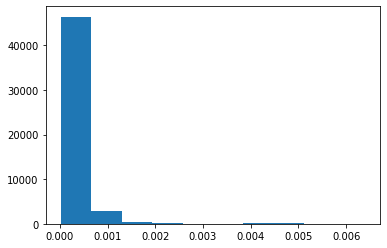

In [22]:
plt.hist(list(coauthor_centralities.values()))
plt.show()

Small world 

In [36]:
import random
random.seed(123)
random_coauthor = random.sample(coauthor_list, 200)
gg_coauthor = nx.Graph()
for author in random_coauthor:
    gg_coauthor.add_node(author[0])
    gg_coauthor.add_node(author[1])
    gg_coauthor.add_edge(author[0],author[1])
print(nx.info(gg_coauthor))

Name: 
Type: Graph
Number of nodes: 317
Number of edges: 198
Average degree:   1.2492


0. Created a directed graph

In [41]:
g_author_di = nx.DiGraph()
for author in coauthor_list:
    g_author_di.add_node(author[0])
    g_author_di.add_node(author[1])
    g_author_di.add_edge(author[0],author[1])
print(nx.info(g_author_di))

Name: 
Type: DiGraph
Number of nodes: 50169
Number of edges: 734696
Average in degree:  14.6444
Average out degree:  14.6444


1. compute the coauthor graph's average clustering coefficient

In [43]:
L = nx.average_clustering(g_author_di)
L

0.9158360612239475

2. compute the coauthor graph's average shorted path

In [68]:
lst_component = []
shortest_path = []
for c in nx.connected_components(g_coauthor):
    sub = g_coauthor.subgraph(c) 
    lst_component.append(sub)
    sp = nx.average_shortest_path_length(sub,method='bellman-ford')
    shortest_path.append(sp)
    print(nx.info(sub))    
    print(sp)

Name: 
Type: Graph
Number of nodes: 4
Number of edges: 6
Average degree:   3.0000
1.0


KeyboardInterrupt: 

In [70]:
march_coauthor = pd.read_csv(r"C:\Users\Louisa Zhao\Desktop\CORD\Data clean\20203\coauthor pairs.csv")

In [71]:
march_coauthor

,source,target
0,Samuel S Minot,Stephen D Turner
1,Stephen D Turner,Samuel S Minot
2,Samuel S Minot,Stephen D Turner
3,Samuel S Minot,Krista L Ternus
4,Stephen D Turner,Samuel S Minot
...,...,...
877513,Gabriel M Leung,Yanrong Wu
877514,Gabriel M Leung,Lingzhai Zhao
877515,Gabriel M Leung,Fuchun Zhang
877516,Gabriel M Leung,Benjamin J Cowling


In [125]:
import random
r = 0.60
n = len(march_coauthor)
num_random = int(r*n)
march_coauthor.sample(num_random).to_csv(r"C:\Users\Louisa Zhao\Desktop\CORD\Data clean\20203\coauthor pairs - random.csv")

In [126]:
def coauthor_pair_csv(coauthor_pair,people_csv_file):
    with open(people_csv_file,'w',encoding='utf-8',newline='') as out:
        csv_out=csv.writer(out)
        csv_out.writerow(['source','target'])
        for row in coauthor_pair:
            csv_out.writerow(row)

In [86]:
lamba = (4.968 / 3.034)
lamba

1.6374423203691497

In [87]:
omega = (0.951/0.005)
omega

190.2

Randomly delete nodes from the graph

In [110]:
import random
r = 0.90
de = int(50169 * r)

random.seed(1)
random_coauthor = random.sample(coauthor_list, de)
gg_coauthor = nx.Graph()
for author in random_coauthor:
    gg_coauthor.add_node(author[0])
    gg_coauthor.add_node(author[1])
    gg_coauthor.add_edge(author[0],author[1])
print(nx.info(gg_coauthor))

Name: 
Type: Graph
Number of nodes: 17836
Number of edges: 34538
Average degree:   3.8728


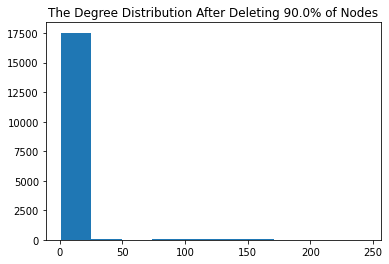

In [111]:
degrees = [gg_coauthor.degree(n) for n in gg_coauthor.nodes()]
plt.hist(degrees)
plt.title("The Degree Distribution After Deleting {}% of Nodes".format(r*100))
plt.show()

community detection using modularity

In [69]:
from networkx.algorithms.community import greedy_modularity_communities
cc = list(greedy_modularity_communities(g_coauthor))

In [71]:
print("We have detect the number of community is :" + str(len(cc)))

We have detect the number of community is :2964


In [72]:
print("We have detect the number of nodes in the first community is :" + str(len(cc[0])))

We have detect the number of nodes in the first community is :6143


In [76]:
cc[0]

frozenset({'Jie  Sun',
           'Fatah  Kashanchi',
           'Di  Liu',
           '• Di Liu',
           'Hua  Guo',
           'Hongli  Jin',
           'Jiang X ',
           'Yanfang  Zhang',
           'Shibu  Yooseph',
           'Han  Zhang',
           'Gao N ',
           'Xin  Li',
           'Dongming  Zhou',
           'Xiaotao  Lu',
           'Zhiping  Li',
           'Matheus P Viana',
           'Xingliang  Fan',
           'Claire E Jones',
           'Qin  Hu',
           'Lai  ',
           'C  Shively',
           'Christopher C Broder',
           'Xiaoyu  Li',
           'JunYong  Yang',
           'Zhiqiang  Qin',
           'Guihong  Zhang',
           'Li  Shasha',
           'Zihao  Li',
           'YiHsien  Hsieh',
           'Jianchi  Guan',
           'Yulan  Sun',
           'Lingzhi  Liu',
           'Lulu  Huang',
           'ChengPing  Hu',
           ' K Y Yuen',
           'Yaqing  He',
           'Santos  Dos',
           'Xiangle  Zhang',
      

1) look at the author properities of community 1

In [81]:
'JunYong  Yang' in author_info_dict

False

In [82]:
for i in cc[0]:
    if i in author_info_dict:
        ins = author_info_dict[i][1]
        if ins != 'NA':
            print(author_info_dict[i][1])

George Mason University
Chinese Academy of Sciences
Chinese Academy of Sciences
Academy of Military Medical Sciences
Chinese Academy of Sciences
China Agricultural University
the First Affiliated Hospital of Guangzhou Medical University
Chinese Academy of Sciences
Vanderbilt University Medical Center
IBM Research Brazil
National Institutes for Food and Drug Control
University of Louisville School of Medicine
Uniformed Services University
Fudan University
South China Agricultural University
Central South University
Nanjing Agricultural University
Chinese Academy of Agricultural Sciences
National Institutes of Health
University of Illinois at Chicago
Euroimmun AG
National Institutes for Food and Drug Control
The University of Hong Kong
Capital Medical University
University of Texas Medical Branch
Wannan Medical College
Mie University Graduate School of Medicine
University of California
University of Minnesota
The University of Hong Kong
Northwest A&F University

Huazhong University of Sc

Huazhong Agricultural University
Zhengzhou University

Gilead Sciences, Inc
Hong Kong Special Administrative Region
Rocky Mountain Laboratories
University of Iowa

University of Pennsylvania
First Affiliated Hospital of Guangzhou Medical University
Polish Academy of Sciences
Wuhan University
The University of Hong Kong

Northwest A&F University
Shanghai Jiaotong University School of Medicine
Huazhong Agricultural University
Jiangxi Agricultural University
National Center for Emerging and Zoonotic Infectious Diseases
University of Washington
University of Tennessee Health Science Center
OHSU Knight Cancer Institute
Sun Yat-sen University
Fudan University


University of Colorado School of Medicine
Huazhong Agricultural University

National Institute for Viral Disease Control and Prevention
Qatar University
China Agricultural University
National Institutes of Health
The University of Sydney
Cognitive and Mental Health Research Center of PLA
Zhongnan Hospital of Wuhan University
Academy o

Chinese Academy of Science
Nankai University
Chinese Academy of Sciences
University of North Carolina at Chapel Hill

Chinese Academy of Sciences
National Institutes of Health
University of 11
Academy of Military Medical Sciences
Harvard Medical School
Southeast University
Northeast Agricultural University
Union Medical College
Harbin Medical University
Hokkaido University
Union Medical College
Fujian Agriculture and Forestry University


Harbin Veterinary Research Institute of the Chinese Academy of Agricultural Sciences
China Agricultural University
The University of Hong Kong
Guangzhou Eighth People's Hospital of Guangzhou Medical University
Sichuan University
Vanderbilt University Medical Center
National Institute for Viral Disease Control and Prevention
Changping District
University of Maryland
Harbin Medical University
Sichuan Agricultural University
Nanjing Agricultural University
Yunnan Institute of Endemic Diseases Control and Prevention
Nanjing Agricultural University
Cornell

In [104]:
nx.density(g_coauthor)

0.00028671106582821017

# 4. Build Institute Collaboration Network

In [191]:
def get_institute(dir_filedata):
    total_ins = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)

        aff_list = []
        for author in data['metadata']['authors']:
            if author['affiliation']:
                aff = author['affiliation']['institution']
                aff_list.append(aff)
        #bring list as a tuple of biparti network
        for i in aff_list:
            for j in aff_list:
                if i != '' and j !='':
                    col = (i,j)
                    total_ins.append(col)
    return total_ins

In [192]:
total_inst_list = get_institute(dir_filedata)

Count the probability of same institute or different

In [198]:
total_inst_list[100:120]

[('Chinese Academy of Sciences', 'Wuhan Jin Yin-Tan Hospital'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Sciences', 'Chinese Academy of Sciences'),
 ('Chinese Academy of Scie

In [207]:
#save it to csv
inst_csv_file = "C:/Users/Louisa Zhao/Desktop/CORD/Data clean/20203/institute.csv"
total_inst_list = coauthor_pair_csv(total_inst_list,inst_csv_file)

In [195]:
same_inst = 0
diff_inst = 0
for pair in total_inst_list:
    if pair[0] == pair[1]:
        same_inst += 1
    if pair[0] != pair[1]:
        diff_inst += 1

In [196]:
print("author from same insitute:",same_inst)

author from same insitute: 219679


In [197]:
print("author from different insitute:",diff_inst)

author from different insitute: 131910


It seems authors tend to collaborate with people from same institute 
*We also need to examine the difference statistically*

In [86]:
#build coauthor network
g_institute = nx.Graph()
for ins in total_inst_list:
    g_institute.add_node(ins[0])
    g_institute.add_node(ins[1])
    g_institute.add_edge(ins[0],ins[1])

In [87]:
print(nx.info(g_institute))

Name: 
Type: Graph
Number of nodes: 4967
Number of edges: 16577
Average degree:   6.6749


Institute Centralities Measure

In [91]:
ins_centralities = nx.degree_centrality(g_institute)
sorted(ins_centralities.items(), reverse = True, key = lambda x:x[1])[:100]

[('Chinese Academy of Sciences', 0.034232782923882404),
 ('University of California', 0.02517116391461941),
 ('University of Oxford', 0.022754732178815948),
 ('National Institutes of Health', 0.022553362867498993),
 ('University of Cambridge', 0.02194925493354813),
 ('University of Toronto', 0.01852597664115989),
 ('Ministry of Health', 0.01852597664115989),
 ('United States of America', 0.016915022150624244),
 ('University of Washington', 0.015304067660088603),
 ('Mahidol University', 0.015102698348771648),
 ('The University of Hong Kong', 0.014699959726137737),
 ('Institut Pasteur', 0.01369311316955296),
 ('Imperial College London', 0.013491743858236005),
 ('Utrecht University', 0.013491743858236005),
 ('University College London', 0.01329037454691905),
 ('University of Amsterdam', 0.013089005235602094),
 ('University of Glasgow', 0.013089005235602094),
 ('Fudan University', 0.012283527990334274),
 ('University of Bern', 0.012283527990334274),
 ('University of Minnesota', 0.012082158

In [96]:
ins_degree = list(g_institute.degree())
sorted(ins_degree, reverse = True, key = lambda x:x[1])[:100]

[('Chinese Academy of Sciences', 170),
 ('University of California', 125),
 ('University of Oxford', 113),
 ('National Institutes of Health', 112),
 ('University of Cambridge', 109),
 ('University of Toronto', 92),
 ('Ministry of Health', 92),
 ('United States of America', 84),
 ('University of Washington', 76),
 ('Mahidol University', 75),
 ('The University of Hong Kong', 73),
 ('Institut Pasteur', 68),
 ('Imperial College London', 67),
 ('Utrecht University', 67),
 ('University College London', 66),
 ('University of Amsterdam', 65),
 ('University of Glasgow', 65),
 ('Fudan University', 61),
 ('University of Bern', 61),
 ('University of Minnesota', 60),
 ('University of Copenhagen', 59),
 ('National Institute of Infectious Diseases', 59),
 ('The Ohio State University', 58),
 ('University of Zurich', 58),
 ('Harvard Medical School', 56),
 ('University of Edinburgh', 55),
 ('Public Health Agency of Canada', 55),
 ('National University of Singapore', 52),
 ('Robert Koch Institute', 52),


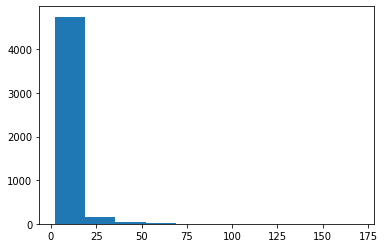

In [101]:
degrees = [g_institute.degree(n) for n in g_institute.nodes()]
plt.hist(degrees)
plt.show()

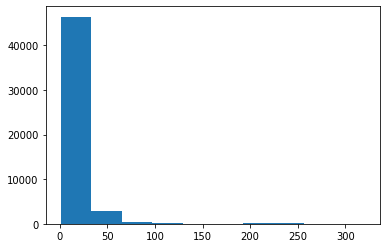

In [106]:
degrees = [g_coauthor.degree(n) for n in g_coauthor.nodes()]
plt.hist(degrees)
plt.show()

In [103]:
nx.density(g_institute)

0.0013441107604997657

# 5. Build paper and reference network

In [79]:
g_paper = nx.Graph()
for paper in reference_node:
    g_paper.add_node(paper[0])
    g_paper.add_node(paper[1])
    g_paper.add_edge(paper[0],paper[1])

In [80]:
print(nx.info(g_paper))

Name: 
Type: Graph
Number of nodes: 353535
Number of edges: 499723
Average degree:   2.8270


In [81]:
nx.density(g_paper)

7.996422485552244e-06

The network density is quite low

In [130]:
import gender_guesser.detector as gender

In [134]:
coauthor_list[:10]

[('Syed  Faraz', 'Ahmed  '),
 ('Ahmed  ', 'Syed  Faraz'),
 ('Syed  Faraz', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed A Quadeer'),
 ('Ahmed  ', 'Syed  Faraz'),
 ('Ahmed  ', 'Ahmed A Quadeer'),
 ('Ahmed A Quadeer', 'Syed  Faraz'),
 ('Ahmed A Quadeer', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed A Quadeer')]

Generate a list of coauthor's first name

In [136]:
#get all pairs of authors
def get_firstname(dir_filedata):
    coauthor_list = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
            
        name_list = data['metadata']['authors']
        one_paper_coauthor = []
        
        for author in name_list:
            first = author['first']

            name = first
            name_clean = name.translate(str.maketrans('', '', string.punctuation))
            one_paper_coauthor.append(name_clean)
            for i in one_paper_coauthor:
                for j in one_paper_coauthor:
                    if i != j:
                        pair=(i,j)
                        coauthor_list.append(pair)
    return coauthor_list

In [61]:
first_name=get_firstname(dir_filedata)

In [144]:
first_name[:10]

[('Syed', 'Ahmed'),
 ('Ahmed', 'Syed'),
 ('Syed', 'Ahmed'),
 ('Syed', 'Ahmed'),
 ('Ahmed', 'Syed'),
 ('Ahmed', 'Syed'),
 ('Syed', 'Ahmed'),
 ('Syed', 'Ahmed'),
 ('Syed', 'Matthew'),
 ('Ahmed', 'Syed')]

In [60]:
def get_firstname(dir_filedata):
    coauthor_list = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
            
        name_list = data['metadata']['authors']
        one_paper_coauthor = []
        
        for author in name_list:
            first = author['first']

            name = first
            name_clean = name.translate(str.maketrans('', '', string.punctuation))
            one_paper_coauthor.append(name_clean)
    return 

In [160]:
%%time
d = gender.Detector()
coauthor_gender = []
for name in first_name[:536438]:
    a = d.get_gender(name[0])
    b = d.get_gender(name[1])
    if a != "unknown" and b != "unknown":
        coauthor_gender.append((a,b))

Wall time: 2.93 s


In [161]:
for name in first_name[536438:10536438]:
    a = d.get_gender(name[0])
    b = d.get_gender(name[1])
    if a != "unknown" and b != "unknown":
        coauthor_gender.append((a,b))

In [158]:
len(first_name)

10036438

In [166]:
len(coauthor_gender)

4860084

In [174]:
%%time
d = gender.Detector()
coauthor_gender_clean = []
for name in first_name[:536438]:
    a = d.get_gender(name[0])
    if a == "male" or a =="female":
        b = d.get_gender(name[1])
        if b == "male" or b =="female":
            coauthor_gender_clean.append((a,b))
        else:
            continue
    else:
        continue

Wall time: 2.75 s


In [175]:
for name in first_name[536438:]:
    a = d.get_gender(name[0])
    if a == "male" or a =="female":
        b = d.get_gender(name[1])
        if b == "male" or b =="female":
            coauthor_gender_clean.append((a,b))
        else:
            continue
    else:
        continue

Exclude the gender detection that is 70% of probabilty, drop the most and unknown gender detector

In [176]:
len(coauthor_gender_clean)

3743002

In [177]:
coauthor_gender_clean[600:1000]

[('female', 'male'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'female'),
 ('female', 'female'),
 ('female', 'female'),
 ('female', 'male'),
 ('female', 'male'),
 ('female', 'female'),
 ('female', 'female'),
 ('female', 'male'),
 ('female', 'male'),
 ('female', 'female'),
 ('female', 'female'),
 ('female', 'male'),
 ('female', 'male'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'male'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'male'),
 ('female', 'female'),
 ('female', 'female'),
 ('female', 'male'),
 ('female', 'male'),
 ('female', 'male'),
 ('female', 'female'),
 ('female', 'female'),
 ('female', 'male'),
 ('female', 'male'),
 ('female', 'male'),
 ('female', 'female'),
 ('female', 'female'),
 ('female', 'male'),
 ('female', 'male'),
 ('female', 'male'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'male'),
 ('male', 'male'),
 ('male', 'female'),
 ('male', 'female'),
 ('male', 'female'

In [187]:
MM = 0
WW = 0
MW = 0
WM = 0
for people in coauthor_gender_clean:
    if people[0] == 'male':
        if people[1] == 'male':
            MM += 1
        else:
            MW += 1
    else:
        if people[1] == 'female':
            WW += 1
        else:
            WM += 1

In [188]:
print(MM,WW,MW,WM)

1624524 485638 816420 816420


In [190]:
total = MM + WW + MW +WM
print(MM/total, WW/total, MW/total, WM/total)

0.4340163323450001 0.12974558923559218 0.21811903920970388 0.21811903920970388


# 5.2 Author institute and geo location

In [63]:
#get zipcode
zip_pair = []
for authors in coauthor_list:
    if authors[0] in author_info_dict:
        loc1 = author_info_dict[authors[0]][2]
    if authors[1] in author_info_dict:
        loc2 = author_info_dict[authors[1]][2]
    if loc1 !='NA' and loc2 !='NA':
        zip_pair.append((loc1,loc2))

In [56]:
print("the pair of lication :",len(zip_pair))

the pair of lication : 551658


In [57]:
same_loc = 0
diff_loc = 0
diff_pair = []
for i in zip_pair:
    if i[0] == i[1]:
        same_loc += 1
    else:
        diff_loc += 1
        diff_pair.append(i)

In [58]:
print("same pair:",same_loc)
print("different pair:",diff_loc)

same pair: 320415
different pair: 231243


In [275]:
diff_pair[:20]

[('OX2 6GG', '61922'),
 ('61922', '44519'),
 ('61922', '44519'),
 ('44519', '61922'),
 ('60612', '200032'),
 ('200032', '60612'),
 ('60612', '200032'),
 ('60612', '10065'),
 ('200032', '60612'),
 ('200032', '10065'),
 ('10065', '60612'),
 ('10065', '200032'),
 ('60612', '200032'),
 ('60612', '10065'),
 ('200032', '60612'),
 ('200032', '10065'),
 ('10065', '60612'),
 ('10065', '200032'),
 ('60612', '200032'),
 ('60612', '10065')]

In [78]:

import pgeocode
dist = pgeocode.GeoDistance('GB')
dist.query_postal_code('WC2N', 'EH53')

ModuleNotFoundError: No module named 'pgeocode'

In [249]:
dist.query_postal_code('200032', '44519')

nan

In [297]:
%%time
dis_lst = []
for pair in diff_pair[:1000]:
    dis = dist.query_postal_code(pair[0],pair[1])
    if np.isnan(dis) == False:
        dis_lst.append(dis)
    #print(dis)

Wall time: 15 s


In [65]:
for pair in diff_pair[15000:35000]:
    dis = dist.query_postal_code(pair[0],pair[1])
    if np.isnan(dis) == False:
        dis_lst.append(dis)

NameError: name 'dist' is not defined

In [300]:
dis_lst

[167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 167.3767050883782,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 1.3404299655220713,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.0055039589801,
 340.00550

viz same geographic location 

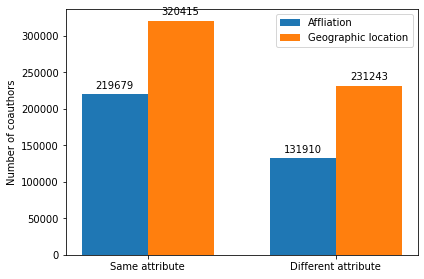

In [85]:
same_pair =  320415
different_pair = 231243

same_ins = 219679
diff_ins = 131910

label = ['Same attribute','Different attribute']
inst = [same_ins,diff_ins]
location = [same_pair,different_pair]

x = np.arange(len(label))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, inst, width, label='Affliation')
rects2 = ax.bar(x + width/2, location, width, label='Geographic location')


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        
ax.set_ylabel('Number of coauthors')
ax.set_xticks(x)
ax.set_xticklabels(label)
ax.legend()

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

# 5.3 Internal similary between reference similarity

Cited references and keyword data are then used to create measures of proximatity in knowledge space

In [36]:
len(reference_node)

508264

In [58]:
%%time
tf = 0
sim_score = []
from sklearn.feature_extraction.text import TfidfVectorizer
vect = TfidfVectorizer(min_df=1, stop_words="english")
for i in reference_node[:1000]:
    tfidf = TfidfVectorizer().fit_transform(i)
    pairwise_similarity = tfidf * tfidf.T
    #print(pairwise_similarity.toarray())
    sim_score.append(pairwise_similarity[1,0])

Wall time: 1.01 s


In [62]:
vect = TfidfVectorizer(min_df=1, stop_words="english")
for i in reference_node[1000:10000]:
    tfidf = TfidfVectorizer().fit_transform(i)
    pairwise_similarity = tfidf * tfidf.T
    #print(pairwise_similarity.toarray())
    sim_score.append(pairwise_similarity[1,0])

In [63]:
len(sim_score)

14221

In [68]:
paper_avg = sum(sim_score) / len(sim_score)
paper_avg

0.10373370101148251

In [49]:
random_citation = []
for i in df_cord_meta['title'][1000:1100]:
    for j in df_cord_meta['title'][600:700]:
        if i != j:
            tup = (i,j)
            random_citation.append(tup)

In [50]:
len(random_citation)

10000

In [51]:
vect = TfidfVectorizer(min_df=1, stop_words="english")
total = 0
sim_score_lst = []
for i in random_citation:
    tfidf = TfidfVectorizer().fit_transform(i)
    pairwise_similarity = tfidf * tfidf.T
    #print(tfidf)
    total += 1
    sim_score = pairwise_similarity[1,0]
    sim_score_lst.append(sim_score)

In [ ]:
random 

In [67]:
avg_random = sum(sim_score_lst) / len(sim_score_lst)
avg_random

0.05264745413354163

In [69]:
max_paper = max(sim_score)
max_paper

1.0000000000000004

In [70]:
max_random = max(sim_score_lst)
max_random

0.436000355678444

In [72]:
from statistics import variance
variance_random = variance(sim_score_lst)
variance_random

0.002769485691602863

In [73]:
variance_paper = variance(sim_score)
variance_paper

0.0270084103779163

ValueError: shape mismatch: objects cannot be broadcast to a single shape

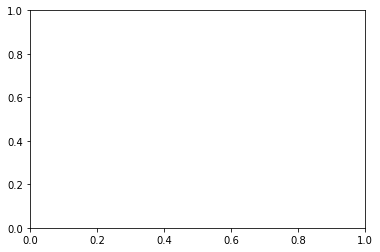

In [84]:
#viz 
label = ['Maximum','Average','Variance']
max_label = [max_paper,max_random]
avg_label = [paper_avg,avg_random]
var_label = [variance_paper,variance_random]

x = np.arange(len(label))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/3, max_label, width, label='Citated pair')
rects2 = ax.bar(x + width/3, avg_label, width, label='Random Pair')



def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 3, height),
                    xytext=(0, 4),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        
ax.set_ylabel('Number of coauthors')
ax.set_xticks(x)
ax.set_xticklabels(label)
ax.legend()

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

In [115]:
print(total)

90
